# Intelligent Automation 2026/27- Assignment 1

To be delivered until 2026-10-09 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `feature_description.txt`.

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import random

sns.set_style('white')   # aspeto dos gráficos: fundo branco sem grelha

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [2]:
df = pd.read_csv("mathematics_grades.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,failed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,False


In [3]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,16.655462,2.795518,2.546218,1.431373,2.042017,0.271709,3.955182,3.246499,3.098039,1.495798,2.330532,3.549020,6.316527,11.268908,11.358543,11.523810
std,1.268262,1.093999,1.084217,0.686075,0.831895,0.671750,0.885721,1.011601,1.090779,0.919886,1.294974,1.402638,8.187623,3.240450,3.147188,3.227797
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,4.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,2.000000,9.000000,9.000000,9.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,14.000000,14.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


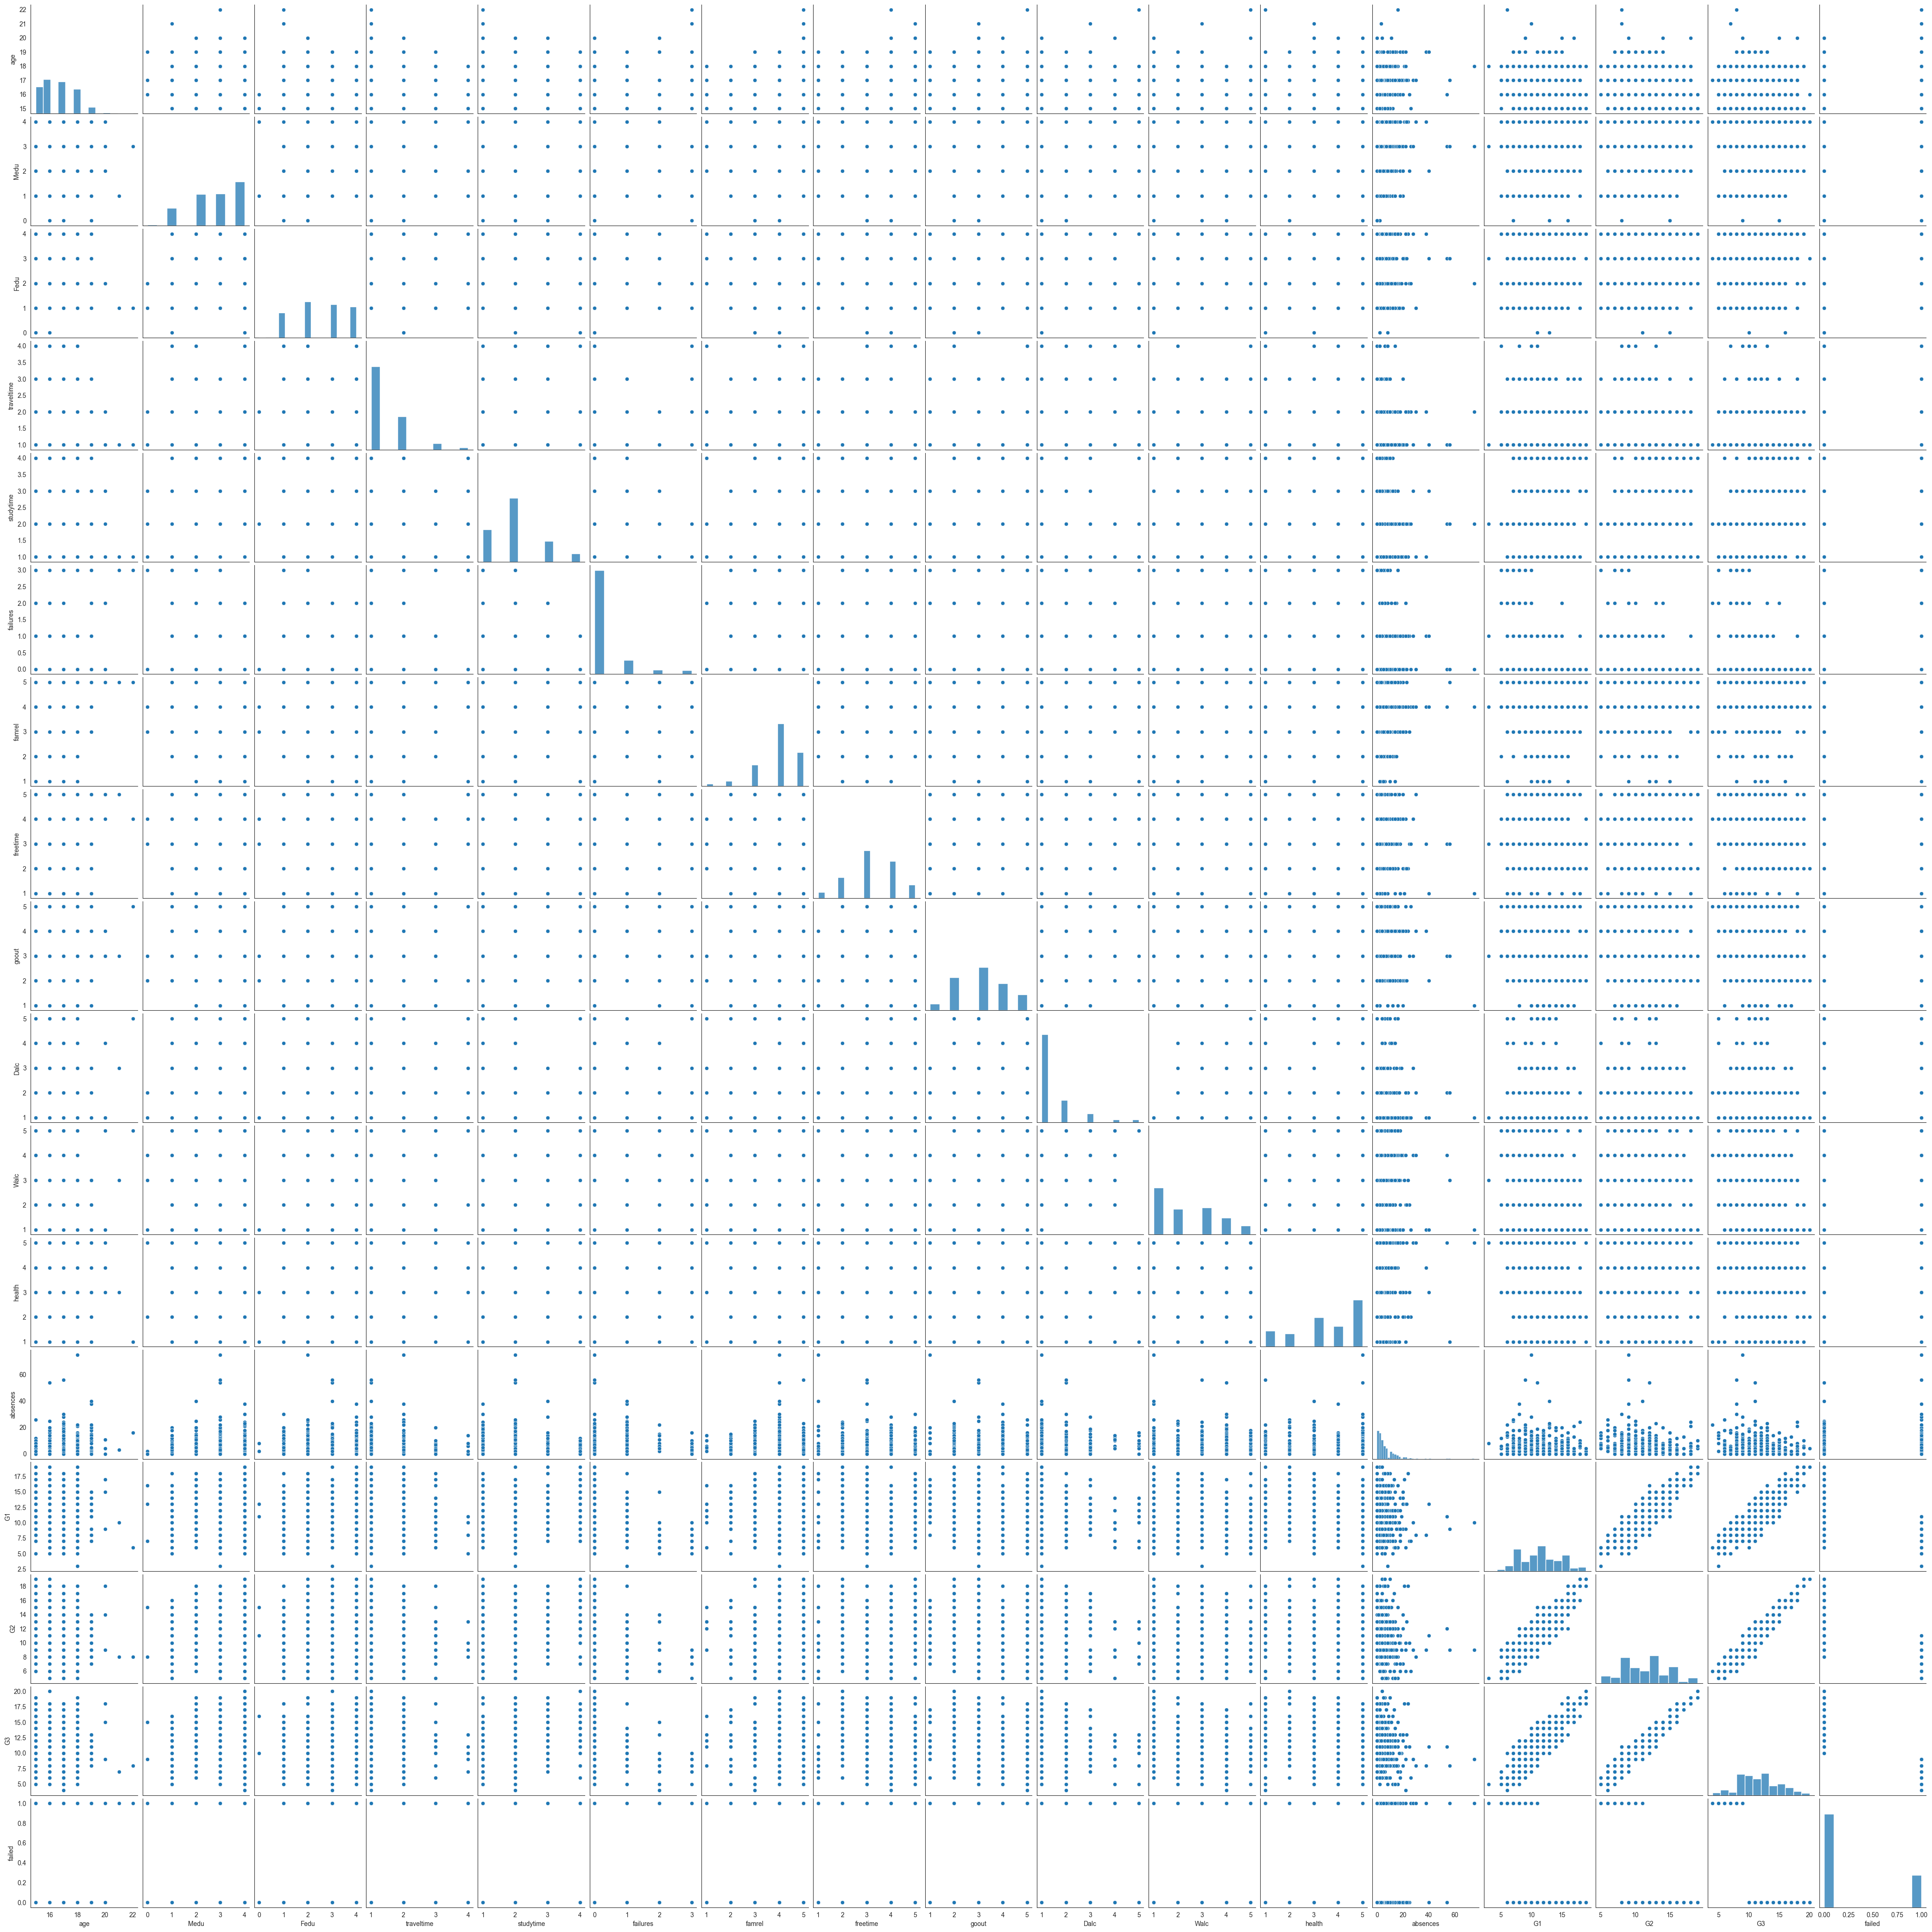

In [4]:
sns.pairplot(data=df) 

##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [5]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
failed          bool
dtype: object

In [6]:
df.nunique()

school         2
sex            2
age            8
address        2
famsize        2
Pstatus        2
Medu           5
Fedu           5
Mjob           5
Fjob           5
reason         4
guardian       3
traveltime     4
studytime      4
failures       4
schoolsup      2
famsup         2
paid           2
activities     2
nursery        2
higher         2
internet       2
romantic       2
famrel         5
freetime       5
goout          5
Dalc           5
Walc           5
health         5
absences      34
G1            16
G2            15
G3            17
failed         2
dtype: int64

In [7]:
binary_vars = ["school", "sex", "address", "famsize", "Pstatus", "schoolsup", "famsup",
               "paid", "activities", "nursery", "higher", "internet", "romantic"]

nominal_vars = ["Mjob", "Fjob", "reason", "guardian"]

ordinal_vars = ["Medu", "Fedu", "traveltime", "studytime", "famrel", "freetime",
                "goout", "Dalc", "Walc", "health"]

numerical_vars = ["age", "failures", "absences", "G1", "G2", "G3"]

categorical_vars = binary_vars + nominal_vars + ordinal_vars

print("Binary:", len(binary_vars), binary_vars)
print("Nominal:", len(nominal_vars), nominal_vars)
print("Ordinal:", len(ordinal_vars), ordinal_vars)
print("Numerical:", len(numerical_vars), numerical_vars)
print("Total:", len(categorical_vars) + len(numerical_vars) + 1)   # +1 is the target 'failed'

Binary: 13 ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Nominal: 4 ['Mjob', 'Fjob', 'reason', 'guardian']
Ordinal: 10 ['Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
Numerical: 6 ['age', 'failures', 'absences', 'G1', 'G2', 'G3']
Total: 34


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [8]:
linhas_vazias = df[df.isnull().any(axis=1)]

if linhas_vazias.empty:
    print("Não há linhas com valores nulos.")
else:
    print("A(s) linha(s) eliminada(s) foi/foram:\n")
    print(linhas_vazias)
    
    df = df.dropna() #Eliminar as linhas do DataFrame original

Não há linhas com valores nulos.


##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

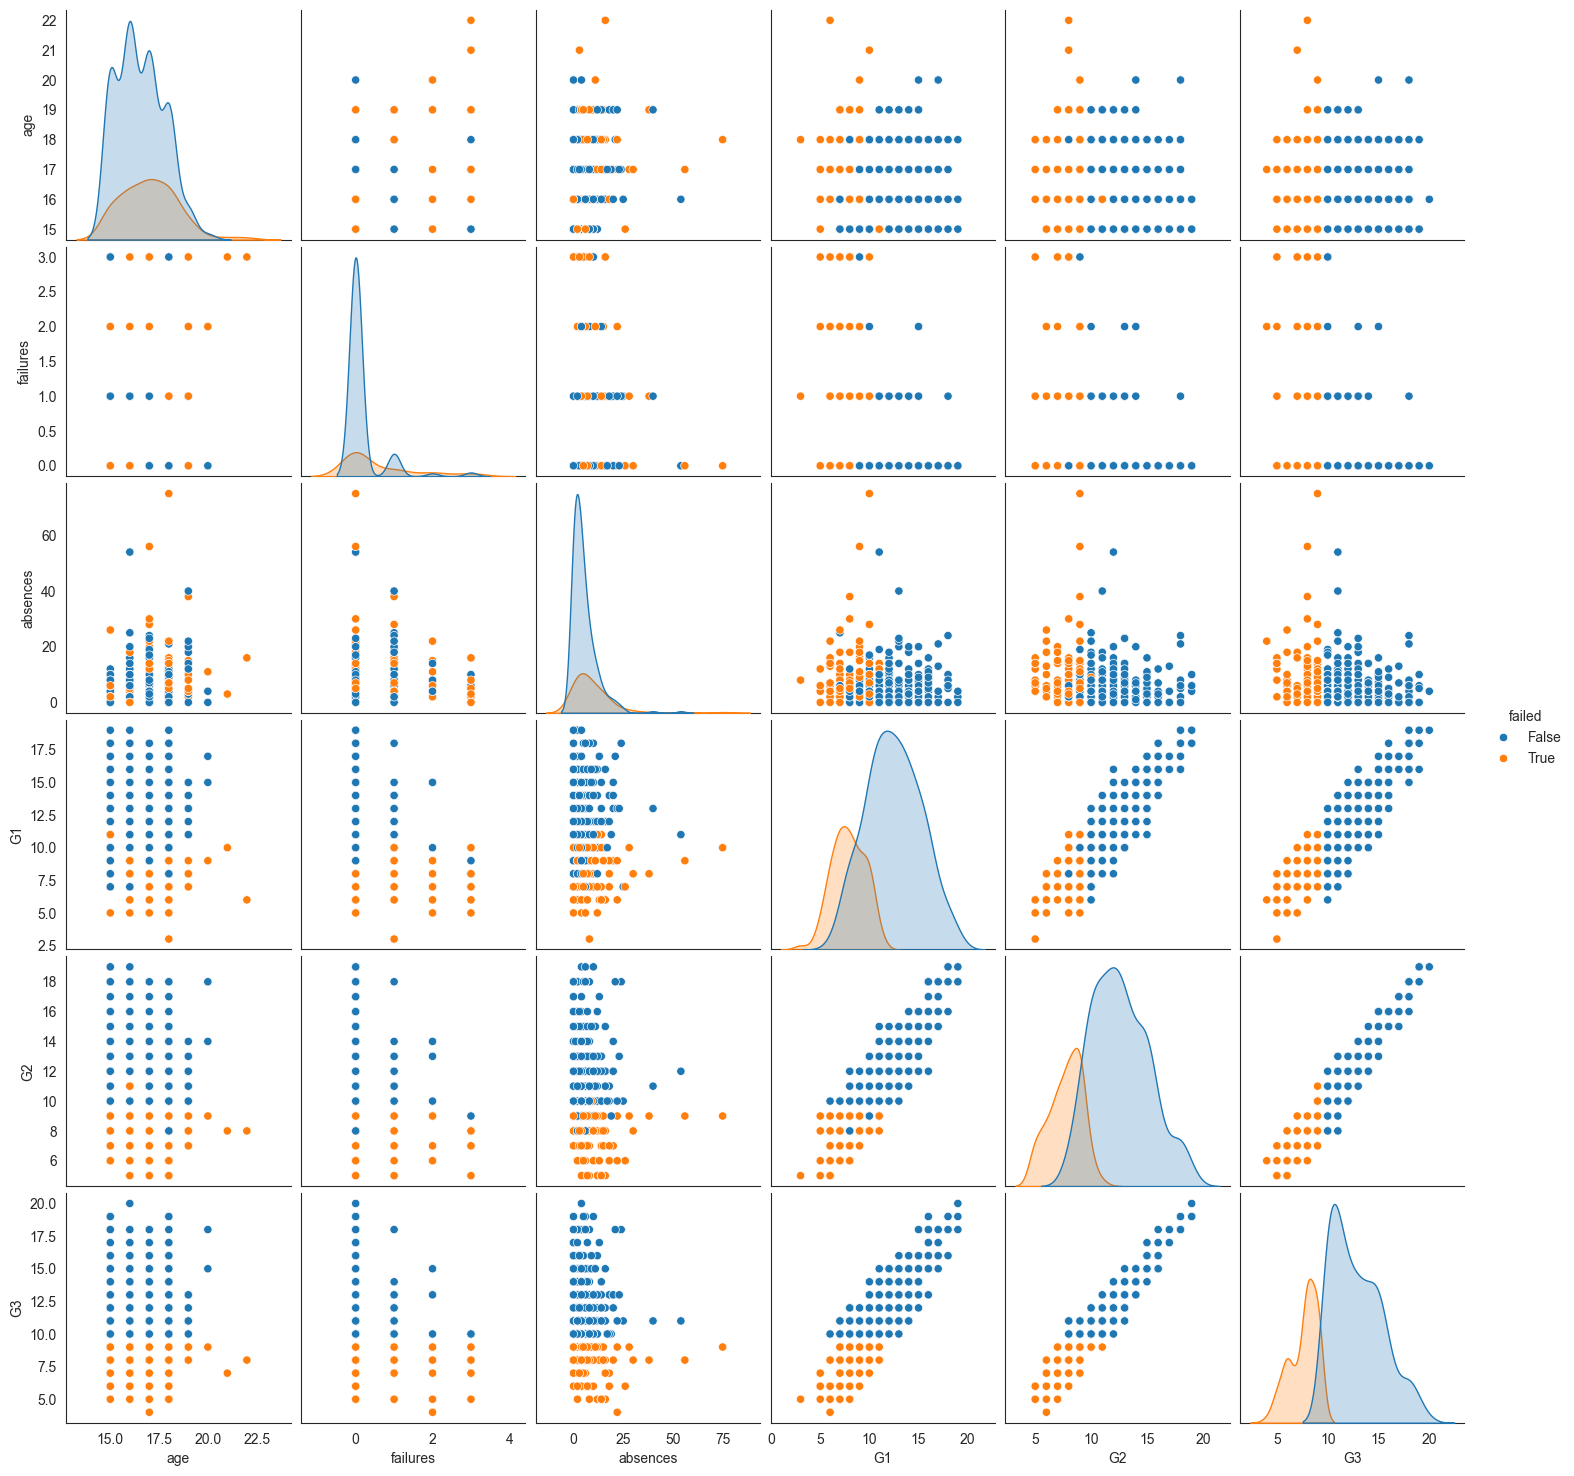

In [9]:
sns.pairplot(df[numerical_vars + ["failed"]], hue="failed")
plt.show()  #Ns se se faz algumas alterações a tamanhos de graficos, densidades das cores das bolas.

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

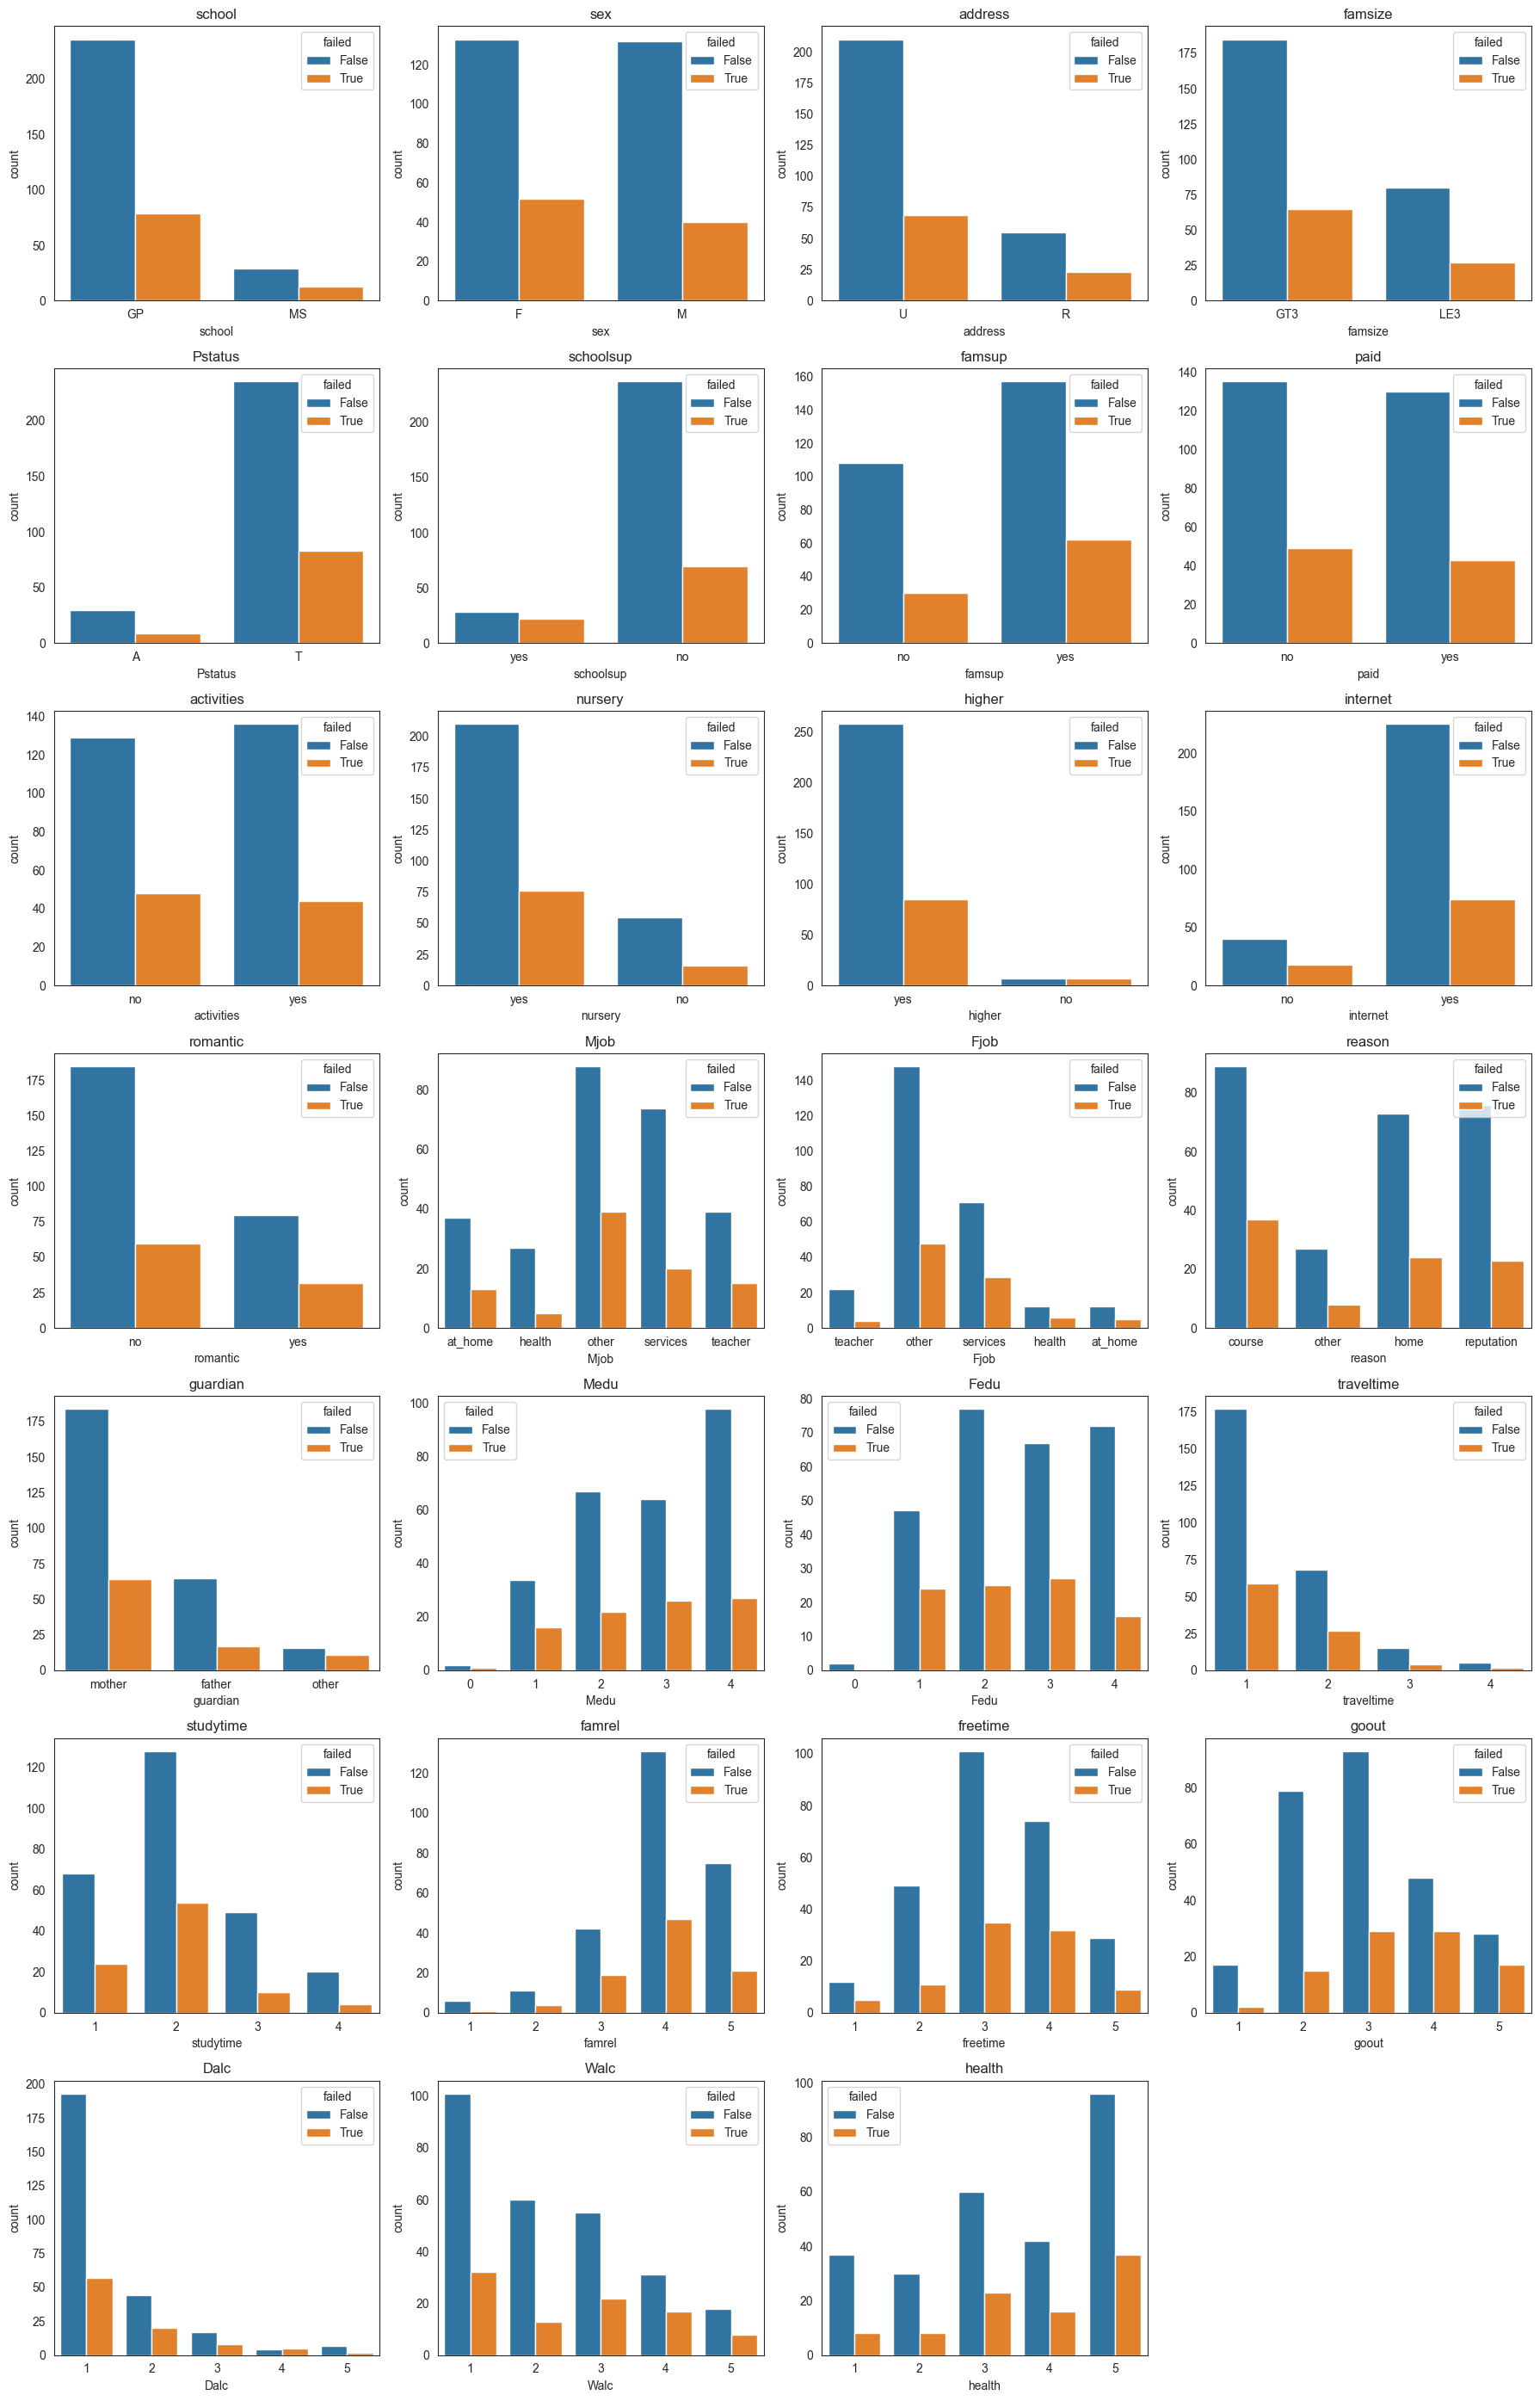

In [10]:
plt.figure(figsize=(18, 28))

i = 1
for var in categorical_vars:
    plt.subplot(7, 4, i)
    sns.countplot(data=df, x=var, hue="failed")
    plt.title(var)
    i = i + 1

plt.tight_layout()
plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [11]:
rural_no_internet = df[(df["address"] == "R") & (df["internet"] == "no")]
rural_no_internet["school"].value_counts()

#rural_no_internet.groupby("school", observed=True).size() assim foi dado nas aulas mas era preciso por o true. Qual escolher ?

school
GP    17
MS     7
Name: count, dtype: int64

##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [ ]:
from sklearn.model_selection import train_test_split

# Combine school and pass/fail status into one column to get a representative sample both for pass/fail but also for MS/GP
df["school_result"] = df["school"].astype(str) + "_" + df["failed"].astype(str)

# This was made because stratify can only separate by one column at a time, so a mix of both columns guarantees 80/20 separation with representativity for both categories
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["school_result"]
)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
147     GP   M   15       R     GT3       T     3     2     other     other   
339     MS   F   18       R     LE3       T     4     4     other     other   
195     GP   M   18       U     GT3       T     2     2  services     other   
164     GP   F   17       U     GT3       T     2     4  services  services   
273     GP   M   18       U     LE3       T     4     4   teacher   teacher   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
50      GP   F   16       U     LE3       T     2     2  services  services   
223     GP   M   16       U     GT3       T     2     1     other     other   
350     MS   F   18       R     GT3       T     4     4   teacher   at_home   
283     GP   F   19       U     LE3       T     1     1   at_home     other   
97      GP   F   16       U     GT3       T     2     1     other     other   

     ... goout Dalc  Walc  health  absences  G1  G2

In [ ]:
train_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,16.592982,2.768421,2.564912,1.428070,2.010526,0.242105,3.971930,3.291228,3.101754,1.459649,2.322807,3.592982,6.133333,11.305263,11.400000,11.547368
std,1.214330,1.117586,1.100655,0.691435,0.815709,0.639913,0.863532,1.015423,1.113378,0.869649,1.289587,1.402696,7.533711,3.255787,3.158044,3.238528
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,5.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,2.000000,9.000000,9.000000,9.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,17.000000,4.000000,4.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,14.000000,14.000000,14.000000
max,21.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,19.000000


# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

The most important performance metric for this classification task should be the Recall metric.
In an educational context, a False Negative (predicting a student will pass when they are actually going to fail) is extremely dangerous, as would be in a health context (predicting a person is healthy when they are actually infected with a disease). A false negative means a struggling student receives extra school support (schoolsup), leading to course failure.

##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,)

# Define predictor and target for test and train sets
X_train = train_df[["absences"]]
y_train = train_df["failed"]

X_test = test_df[["absences"]]
y_test = test_df["failed"]

# Use comand for logistic regression and train the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Print metric results
print("Confusion Matrix:\n", cm)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion Matrix:
 [[51  2]
 [17  2]]
Accuracy:  0.7361
Precision: 0.5000
Recall:    0.1053
F1-score:  0.1739


##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

The model indeed does not work well, as it shows a low recall value. This means that the model can predict very few out of all failing students. This could be due to the fact that only the "absence" feature is being used as a predictor. Alone this feature is a bad predictor, to improve the model, we should use other features that better relate to the failing results or use more features to improve the predictor set.

##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

In [ ]:
# Confirm "studytime" is a numerical variable:
print(df.dtypes["studytime"])

# Since the result is int64 we confirm the variable is numerical, if it weren't we could use the comand:
# df["studytime"] = pd.to_numeric(df["studytime"])

int64


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,)

# Define predictor and target for test and train sets
X_train = train_df[["studytime"]]
y_train = train_df["failed"]

X_test = test_df[["studytime"]]
y_test = test_df["failed"]

# Use comand for logistic regression and train the model
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Print metric results
print("Confusion Matrix:\n", cm)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion Matrix:
 [[41 12]
 [15  4]]
Accuracy:  0.6250
Precision: 0.2500
Recall:    0.2105
F1-score:  0.2286


##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

In [25]:
# Convert "studytime" into a categorical column and apply One-Hot Encoding
df["studytime"] = df["studytime"].astype("category")
df_encoded = pd.get_dummies(df, columns=["studytime"], prefix="studytime", drop_first=True)

# Create the train/test split 
df_encoded["school_result"] = df_encoded["school"].astype(str) + "_" + df_encoded["failed"].astype(str)
train_df, test_df = train_test_split(df_encoded, test_size=0.20, random_state=42, stratify=df_encoded["school_result"])

# 4. Define feature columns (the generated dummy variables) and target
feature_cols = [col for col in df_encoded.columns if col.startswith("studytime_")]

X_train = train_df[feature_cols]
y_train = train_df["failed"]

X_test = test_df[feature_cols]
y_test = test_df["failed"]

# 5. Train Logistic Regression with class_weight='balanced'
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

# 6. Predict on the test set
y_pred = model.predict(X_test)

# 7. Evaluate performance metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Confusion Matrix:\n", cm)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion Matrix:
 [[19 34]
 [ 2 17]]
Accuracy:  0.5000
Precision: 0.3333
Recall:    0.8947
F1-score:  0.4857


##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


c:\Users\User\miniconda3\envs\automacao-inteligente\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


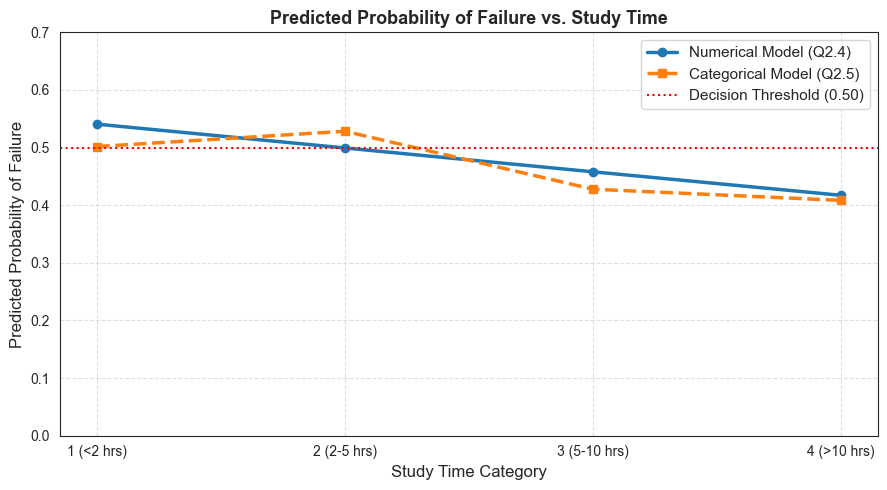

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Load data and setup stratified split
df = pd.read_csv("mathematics_grades.csv")
df["school_result"] = df["school"].astype(str) + "_" + df["failed"].astype(str)

# --- Numerical Model (Q2.4) ---
train_num, test_num = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["school_result"]
)
model_num = LogisticRegression(class_weight="balanced", random_state=42)
model_num.fit(train_num[["studytime"]], train_num["failed"])

# --- Categorical Model (Q2.5) ---
df_cat = pd.get_dummies(
    df, columns=["studytime"], prefix="studytime", drop_first=True
)
df_cat["school_result"] = df_cat["school"].astype(str) + "_" + df_cat["failed"].astype(str)
train_cat, test_cat = train_test_split(
    df_cat, test_size=0.20, random_state=42, stratify=df_cat["school_result"]
)

feature_cols = [c for c in train_cat.columns if c.startswith("studytime_")]
model_cat = LogisticRegression(class_weight="balanced", random_state=42)
model_cat.fit(train_cat[feature_cols], train_cat["failed"])

# --- Compute predicted failure probabilities across studytime range [1, 2, 3, 4] ---
studytime_vals = np.array([1, 2, 3, 4])
prob_num = model_num.predict_proba(studytime_vals.reshape(-1, 1))[:, 1]

cat_inputs = pd.DataFrame(
    {
        "studytime_2": [0, 1, 0, 0],
        "studytime_3": [0, 0, 1, 0],
        "studytime_4": [0, 0, 0, 1],
    }
)
prob_cat = model_cat.predict_proba(cat_inputs)[:, 1]

# --- Plotting the predictions ---
plt.figure(figsize=(9, 5))
plt.plot(
    studytime_vals,
    prob_num,
    marker="o",
    linewidth=2.5,
    label="Numerical Model (Q2.4)",
    color="#1f77b4",
)
plt.plot(
    studytime_vals,
    prob_cat,
    marker="s",
    linewidth=2.5,
    linestyle="--",
    label="Categorical Model (Q2.5)",
    color="#ff7f0e",
)
plt.axhline(0.5, color="red", linestyle=":", label="Decision Threshold (0.50)")

plt.xticks(
    [1, 2, 3, 4], ["1 (<2 hrs)", "2 (2-5 hrs)", "3 (5-10 hrs)", "4 (>10 hrs)"]
)
plt.xlabel("Study Time Category", fontsize=12)
plt.ylabel("Predicted Probability of Failure", fontsize=12)
plt.title(
    "Predicted Probability of Failure vs. Study Time",
    fontsize=13,
    fontweight="bold",
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

The main difference between the two models is the way the model interprets the "studytime" variable. In the first one of them (question 2.4), "studytime" is just read as a numerical variable (the way it was defined in the mathematics_grades dataset). In the second one (question 2.5), "studytime" is transformed into a categorical variable. This means that the model treats entries in this column as different categories and associates different mathematical parameters to each one of them to try to relate the predictor and the prediction. Also, using "studytime" as a numerical variable, means that the model has a more simplified interpretation of what is happening to make its predictions (higher values for studytime means more probability to pass) and defines a more linear relation for predictor/prediction.

For the first model, this linear mathematical relationship meant that having a studytime = 2, the prediction was placed under the 0.5 threshold and the model predicted that that student would fail with a probability of 49.93%, placing it under the 0.5 threshold. As for the second model, the estimation for studytime = 2 was failure with a 52.83% probability, pushing it above the 0.50 threshold. And, since studytime = 2 represents the majority of failing students in the test set, classifying studytime = 2 as Fail increases Recall from 21.05% to 89.47%. 

# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**

##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

# Part 5 - GitHub (1.00)

##### **5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**